In [ ]:
import tensor 

In [1]:
from tensorflow.keras.datasets import mnist

# loading the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
# let's print the shape of the dataset


ModuleNotFoundError: No module named 'tensorflow'

In [28]:
import matplotlib.pyplot as plt
import numpy as np

(28, 28)


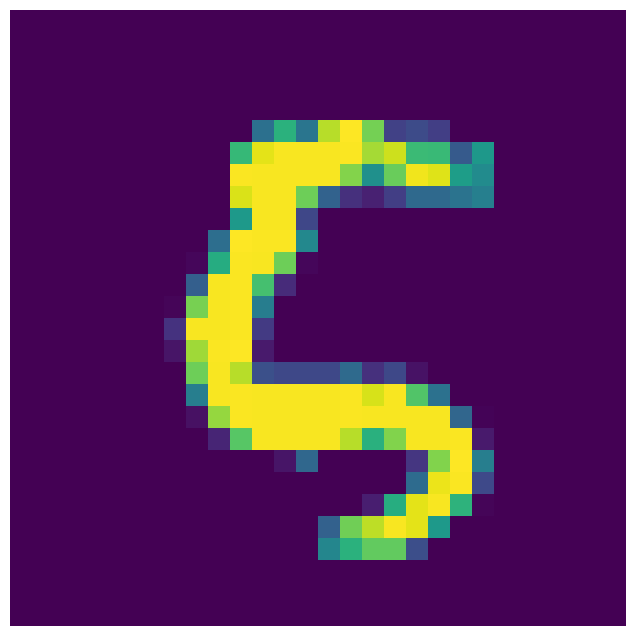

In [29]:
plt.figure(figsize=(8, 8))
plt.imshow(X_train[2000])
plt.axis("off")

print(X_train[2000].shape)


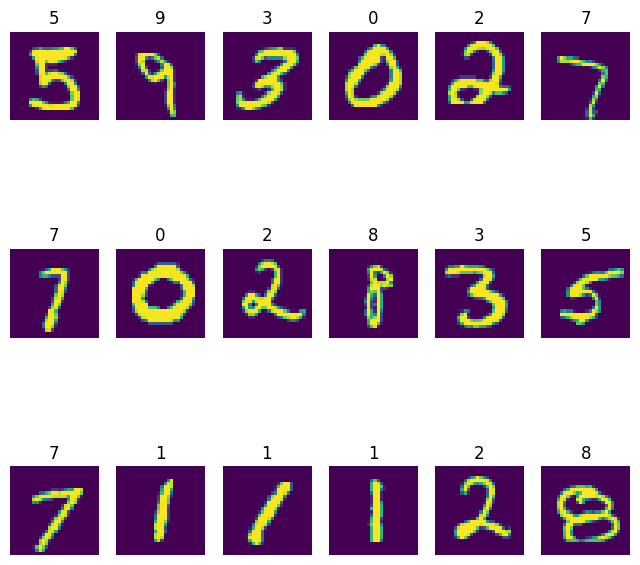

In [30]:
#Visualising the MNIST Samples

plt.figure(figsize=(8, 8))
for i in range(18):
  plt.subplot(3, 6, i + 1)
  fignum = np.random.randint(1, high=5000)
  plt.imshow(X_train[fignum])
  #plt.imshow(cv2.resize(X_train[fignum], (28, 28)))
  plt.title(y_train[fignum])
  plt.axis("off")

In [31]:
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

X_train shape (60000, 28, 28)
y_train shape (60000,)
X_test shape (10000, 28, 28)
y_test shape (10000,)


In [32]:
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [33]:
print("Shape after RESHAPING")
print("X_train shape", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)

Shape after RESHAPING
X_train shape (60000, 28, 28, 1)
y_train shape (60000,)
X_test shape (10000, 28, 28, 1)
y_test shape (10000,)


In [34]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
# one-hot encoding using keras' numpy-related utilities
n_classes = 10

print("Train Shape before one-hot encoding: ", y_train.shape)
print("Test Shape before one-hot encoding: ", y_test.shape)
y_train = to_categorical(y_train, n_classes)
y_test = to_categorical(y_test, n_classes)
print("Train Shape after one-hot encoding: ", y_train.shape)
print("Test Shape after one-hot encoding: ", y_test.shape)

Train Shape before one-hot encoding:  (60000,)
Test Shape before one-hot encoding:  (10000,)
Train Shape after one-hot encoding:  (60000, 10)
Test Shape after one-hot encoding:  (10000, 10)


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import InputLayer

In [54]:
# building a linear stack of layers with the sequential model
model = Sequential()
inputshape = (28,28,1)
# convolutional layer
model.add(Conv2D(10, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu', input_shape=inputshape))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(10, kernel_size=(3,3), strides=(1,1), padding='valid', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# flatten output of conv
model.add(Flatten())
# hidden layer
model.add(Dense(100, activation='relu'))
# output layer
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 26, 26, 10)          │             100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 13, 13, 10)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 11, 11, 10)          │             910 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 5, 5, 10)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 100)                 │          25,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │           1,010 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,120 (105.94 KB)

 Trainable params: 27,120 (105.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# compiling the sequential model
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='Adam')
# training the model for 10 epochs
model.fit(X_train, y_train, batch_size=64, epochs=3, validation_data=(X_test, y_test))

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.7844 - loss: 2.6227 - val_accuracy: 0.9589 - val_loss: 0.1409
Epoch 2/3
809/938 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9667 - loss: 0.1136